In [15]:
import pandas as pd
import numpy as np
import importlib.util

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

print("Scikit-learn installed:",
      importlib.util.find_spec("sklearn") is not None)

print("XGBoost installed:",
      importlib.util.find_spec("xgboost") is not None)

Pandas: 3.0.5
NumPy: 2.5.3
Scikit-learn installed: True
XGBoost installed: True


In [16]:
import sys

print(sys.executable)

c:\Users\pc xpertz\Predictive-Public-Transit-Intelligence-Platform-for-Crowd-Management-and-Schedule-Optimization\backend\venv\Scripts\python.exe


In [17]:
import pandas as pd

entries_path = "../data/bmrcl/station-hourly.csv"
exits_path = "../data/bmrcl/station-hourly-exits.csv"

entries_df = pd.read_csv(
    entries_path,
    sep=";"
)

exits_df = pd.read_csv(
    exits_path,
    sep=";"
)

print("Entries shape:", entries_df.shape)
print("Exits shape:", exits_df.shape)

print("\nEntries columns:")
print(entries_df.columns.tolist())

print("\nExits columns:")
print(exits_df.columns.tolist())

Entries shape: (92280, 4)
Exits shape: (95616, 4)

Entries columns:
['Date', 'Hour', 'Station', 'Ridership']

Exits columns:
['Date', 'Hour', 'Station', 'Ridership']


In [18]:
# Merge entries and exits
ml_df = pd.merge(
    entries_df,
    exits_df,
    on=["Date", "Hour", "Station"],
    how="inner",
    suffixes=("_entry", "_exit")
)

# Calculate net passenger flow
ml_df["Net_Flow"] = (
    ml_df["Ridership_entry"]
    - ml_df["Ridership_exit"]
)

print("ML dataset shape:", ml_df.shape)

print("\nColumns:")
print(ml_df.columns.tolist())

print("\nFirst 5 rows:")
display(ml_df.head())

ML dataset shape: (92280, 6)

Columns:
['Date', 'Hour', 'Station', 'Ridership_entry', 'Ridership_exit', 'Net_Flow']

First 5 rows:


,Date,Hour,Station,Ridership_entry,Ridership_exit,Net_Flow
0,2025-08-01,0,Attiguppe,0,0,0
1,2025-08-01,1,Attiguppe,0,0,0
2,2025-08-01,2,Attiguppe,0,0,0
3,2025-08-01,3,Attiguppe,0,0,0
4,2025-08-01,4,Attiguppe,6,0,6


In [19]:
# Convert Date into datetime
ml_df["Date"] = pd.to_datetime(ml_df["Date"])

# Time-based features
ml_df["Day_of_Week"] = ml_df["Date"].dt.dayofweek
ml_df["Day_of_Month"] = ml_df["Date"].dt.day
ml_df["Month"] = ml_df["Date"].dt.month

# Weekend indicator
ml_df["Is_Weekend"] = (
    ml_df["Day_of_Week"] >= 5
).astype(int)

# Peak-period indicator
ml_df["Is_Peak_Hour"] = (
    ml_df["Hour"].isin([7, 8, 9, 17, 18, 19])
).astype(int)

print("Feature engineering completed.")

print("\nUpdated columns:")
print(ml_df.columns.tolist())

print("\nSample:")
display(
    ml_df[
        [
            "Date",
            "Hour",
            "Station",
            "Day_of_Week",
            "Is_Weekend",
            "Is_Peak_Hour"
        ]
    ].head()
)

Feature engineering completed.

Updated columns:
['Date', 'Hour', 'Station', 'Ridership_entry', 'Ridership_exit', 'Net_Flow', 'Day_of_Week', 'Day_of_Month', 'Month', 'Is_Weekend', 'Is_Peak_Hour']

Sample:


,Date,Hour,Station,Day_of_Week,Is_Weekend,Is_Peak_Hour
0,2025-08-01,0,Attiguppe,4,0,0
1,2025-08-01,1,Attiguppe,4,0,0
2,2025-08-01,2,Attiguppe,4,0,0
3,2025-08-01,3,Attiguppe,4,0,0
4,2025-08-01,4,Attiguppe,4,0,0


In [20]:
# Sort data correctly before creating historical features
ml_df = ml_df.sort_values(
    ["Station", "Date", "Hour"]
).reset_index(drop=True)

# Previous-hour ridership for each station
ml_df["Previous_Hour_Ridership"] = (
    ml_df.groupby("Station")["Ridership_entry"]
    .shift(1)
)

# Previous-day ridership for the same station and hour
ml_df["Previous_Day_Ridership"] = (
    ml_df.groupby("Station")["Ridership_entry"]
    .shift(24)
)

# 3-hour rolling average of previous demand
ml_df["Rolling_3H_Avg"] = (
    ml_df.groupby("Station")["Ridership_entry"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

print("Historical demand features created.")

print("\nNew columns:")
print([
    "Previous_Hour_Ridership",
    "Previous_Day_Ridership",
    "Rolling_3H_Avg"
])

print("\nSample:")
display(
    ml_df[
        [
            "Date",
            "Hour",
            "Station",
            "Ridership_entry",
            "Previous_Hour_Ridership",
            "Previous_Day_Ridership",
            "Rolling_3H_Avg"
        ]
    ].head(30)
)

Historical demand features created.

New columns:
['Previous_Hour_Ridership', 'Previous_Day_Ridership', 'Rolling_3H_Avg']

Sample:


,Date,Hour,Station,Ridership_entry,Previous_Hour_Ridership,Previous_Day_Ridership,Rolling_3H_Avg
0,2025-08-01,0,Attiguppe,0,NaN,NaN,NaN
1,2025-08-01,1,Attiguppe,0,0.0,NaN,NaN
2,2025-08-01,2,Attiguppe,0,0.0,NaN,NaN
3,2025-08-01,3,Attiguppe,0,0.0,NaN,0.000000
4,2025-08-01,4,Attiguppe,6,0.0,NaN,0.000000
5,2025-08-01,5,Attiguppe,65,6.0,NaN,2.000000
6,2025-08-01,6,Attiguppe,219,65.0,NaN,23.666667
7,2025-08-01,7,Attiguppe,646,219.0,NaN,96.666667
8,2025-08-01,8,Attiguppe,1338,646.0,NaN,310.000000
9,2025-08-01,9,Attiguppe,1818,1338.0,NaN,734.333333


In [21]:
# Historical exit and net-flow features

ml_df["Previous_Hour_Exit"] = (
    ml_df.groupby("Station")["Ridership_exit"]
    .shift(1)
)

ml_df["Previous_Hour_Net_Flow"] = (
    ml_df.groupby("Station")["Net_Flow"]
    .shift(1)
)

print("Exit and flow history features created.")

print("\nSample:")
display(
    ml_df[
        [
            "Date",
            "Hour",
            "Station",
            "Ridership_entry",
            "Ridership_exit",
            "Net_Flow",
            "Previous_Hour_Exit",
            "Previous_Hour_Net_Flow"
        ]
    ].head(30)
)

Exit and flow history features created.

Sample:


,Date,Hour,Station,Ridership_entry,Ridership_exit,Net_Flow,Previous_Hour_Exit,Previous_Hour_Net_Flow
0,2025-08-01,0,Attiguppe,0,0,0,NaN,NaN
1,2025-08-01,1,Attiguppe,0,0,0,0.0,0.0
2,2025-08-01,2,Attiguppe,0,0,0,0.0,0.0
3,2025-08-01,3,Attiguppe,0,0,0,0.0,0.0
4,2025-08-01,4,Attiguppe,6,0,6,0.0,0.0
5,2025-08-01,5,Attiguppe,65,27,38,0.0,6.0
6,2025-08-01,6,Attiguppe,219,67,152,27.0,38.0
7,2025-08-01,7,Attiguppe,646,106,540,67.0,152.0
8,2025-08-01,8,Attiguppe,1338,231,1107,106.0,540.0
9,2025-08-01,9,Attiguppe,1818,227,1591,231.0,1107.0


In [22]:
# Check missing values in the ML dataset

missing_values = ml_df.isnull().sum()

missing_percentage = (
    ml_df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

print("Missing-value summary:")
display(
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
)

Missing-value summary:


,Missing_Count,Missing_Percentage
Previous_Hour_Ridership,83,0.09
Previous_Day_Ridership,1992,2.16
Rolling_3H_Avg,249,0.27
Previous_Hour_Exit,83,0.09
Previous_Hour_Net_Flow,83,0.09


In [23]:
# Keep only rows with complete historical features

historical_features = [
    "Previous_Hour_Ridership",
    "Previous_Day_Ridership",
    "Rolling_3H_Avg",
    "Previous_Hour_Exit",
    "Previous_Hour_Net_Flow"
]

ml_model_df = ml_df.dropna(
    subset=historical_features
).copy()

print("Original rows:", len(ml_df))
print("Rows available for ML:", len(ml_model_df))
print("Rows removed:", len(ml_df) - len(ml_model_df))

print("\nRemaining missing values:")
print(
    ml_model_df[historical_features]
    .isnull()
    .sum()
)

Original rows: 92280
Rows available for ML: 90288
Rows removed: 1992

Remaining missing values:
Previous_Hour_Ridership    0
Previous_Day_Ridership     0
Rolling_3H_Avg             0
Previous_Hour_Exit         0
Previous_Hour_Net_Flow     0
dtype: int64


In [24]:
# Create the target: next-hour station ridership

ml_model_df["Target_Next_Hour_Ridership"] = (
    ml_model_df.groupby("Station")["Ridership_entry"]
    .shift(-1)
)

print("Target created.")

print("\nSample:")
display(
    ml_model_df[
        [
            "Date",
            "Hour",
            "Station",
            "Ridership_entry",
            "Target_Next_Hour_Ridership"
        ]
    ].head(30)
)

print(
    "\nMissing target values:",
    ml_model_df["Target_Next_Hour_Ridership"].isnull().sum()
)

Target created.

Sample:


,Date,Hour,Station,Ridership_entry,Target_Next_Hour_Ridership
24,2025-08-02,0,Attiguppe,0,0.0
25,2025-08-02,1,Attiguppe,0,0.0
26,2025-08-02,2,Attiguppe,0,0.0
27,2025-08-02,3,Attiguppe,0,10.0
28,2025-08-02,4,Attiguppe,10,62.0
29,2025-08-02,5,Attiguppe,62,174.0
30,2025-08-02,6,Attiguppe,174,413.0
31,2025-08-02,7,Attiguppe,413,646.0
32,2025-08-02,8,Attiguppe,646,1110.0
33,2025-08-02,9,Attiguppe,1110,780.0



Missing target values: 83


In [25]:
# Remove rows where the prediction target is unavailable

ml_model_df = ml_model_df.dropna(
    subset=["Target_Next_Hour_Ridership"]
).copy()

print("Final ML dataset shape:", ml_model_df.shape)

print(
    "Missing target values:",
    ml_model_df["Target_Next_Hour_Ridership"].isnull().sum()
)

Final ML dataset shape: (90205, 17)
Missing target values: 0


In [26]:
# Define features and prediction target

feature_columns = [
    "Hour",
    "Day_of_Week",
    "Day_of_Month",
    "Month",
    "Is_Weekend",
    "Is_Peak_Hour",
    "Ridership_entry",
    "Ridership_exit",
    "Net_Flow",
    "Previous_Hour_Ridership",
    "Previous_Day_Ridership",
    "Rolling_3H_Avg",
    "Previous_Hour_Exit",
    "Previous_Hour_Net_Flow"
]

X = ml_model_df[feature_columns]

y = ml_model_df["Target_Next_Hour_Ridership"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Feature matrix shape: (90205, 14)
Target shape: (90205,)

Features:
['Hour', 'Day_of_Week', 'Day_of_Month', 'Month', 'Is_Weekend', 'Is_Peak_Hour', 'Ridership_entry', 'Ridership_exit', 'Net_Flow', 'Previous_Hour_Ridership', 'Previous_Day_Ridership', 'Rolling_3H_Avg', 'Previous_Hour_Exit', 'Previous_Hour_Net_Flow']

Target:
Target_Next_Hour_Ridership


In [27]:
from sklearn.preprocessing import OneHotEncoder

# Encode station names
station_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

station_encoded = station_encoder.fit_transform(
    ml_model_df[["Station"]]
)

station_feature_names = (
    station_encoder.get_feature_names_out(["Station"])
)

station_df = pd.DataFrame(
    station_encoded,
    columns=station_feature_names,
    index=ml_model_df.index
)

# Add station features to the numerical feature matrix
X = pd.concat(
    [
        X,
        station_df
    ],
    axis=1
)

print("Updated feature matrix shape:", X.shape)

print(
    "Number of station features:",
    len(station_feature_names)
)

print("\nFirst 5 station features:")
print(station_feature_names[:5])

Updated feature matrix shape: (90205, 97)
Number of station features: 83

First 5 station features:
['Station_Attiguppe' 'Station_BTM Layout' 'Station_Baiyappanahalli'
 'Station_Banashankari' 'Station_Benniganahalli']


In [28]:
# Create a chronological train-test split

sorted_indices = ml_model_df["Date"].sort_values().index

X_sorted = X.loc[sorted_indices]
y_sorted = y.loc[sorted_indices]

split_index = int(len(X_sorted) * 0.80)

X_train = X_sorted.iloc[:split_index]
X_test = X_sorted.iloc[split_index:]

y_train = y_sorted.iloc[:split_index]
y_test = y_sorted.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(
    ml_model_df.loc[X_train.index, "Date"].min(),
    "to",
    ml_model_df.loc[X_train.index, "Date"].max()
)

print("\nTesting period:")
print(
    ml_model_df.loc[X_test.index, "Date"].min(),
    "to",
    ml_model_df.loc[X_test.index, "Date"].max()
)

Training samples: 72164
Testing samples: 18041

Training period:
2025-08-02 00:00:00 to 2025-09-21 00:00:00

Testing period:
2025-09-21 00:00:00 to 2025-09-30 00:00:00


In [29]:
from xgboost import XGBRegressor

# Create the XGBoost regression model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model training completed.")

XGBoost model training completed.


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions on unseen test data
y_pred = xgb_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("XGBoost Model Performance")
print("--------------------------")
print(f"MAE  : {mae:.2f} passengers")
print(f"RMSE : {rmse:.2f} passengers")
print(f"R²   : {r2:.4f}")

XGBoost Model Performance
--------------------------
MAE  : 46.85 passengers
RMSE : 87.11 passengers
R²   : 0.9682


In [31]:
# Baseline: predict next-hour ridership
# using the current-hour ridership

baseline_predictions = (
    ml_model_df.loc[X_test.index, "Ridership_entry"]
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline Model Performance")
print("--------------------------")
print(f"MAE  : {baseline_mae:.2f} passengers")
print(f"RMSE : {baseline_rmse:.2f} passengers")
print(f"R²   : {baseline_r2:.4f}")

Baseline Model Performance
--------------------------
MAE  : 127.22 passengers
RMSE : 235.88 passengers
R²   : 0.7667


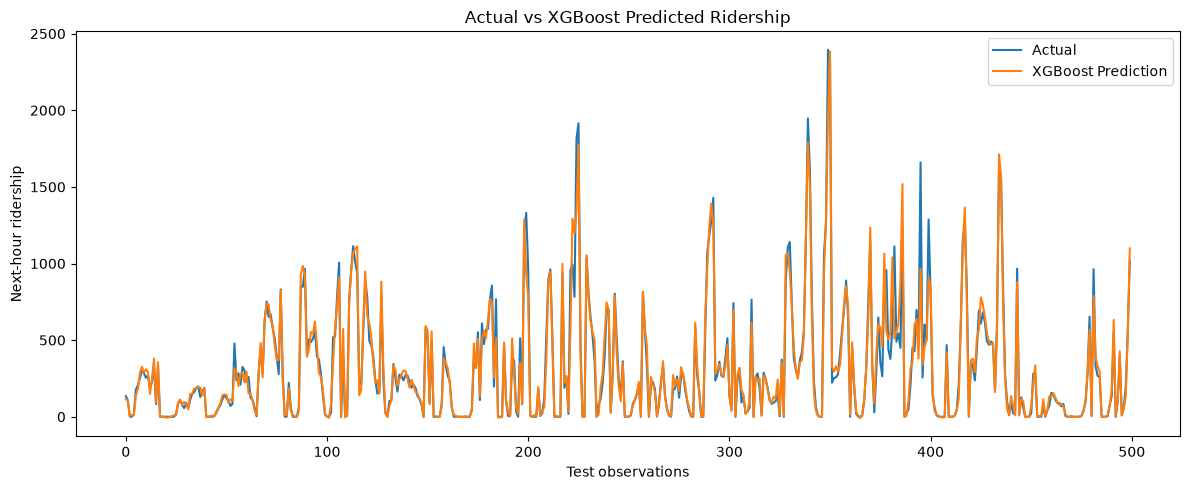

In [32]:
import matplotlib.pyplot as plt

# Compare actual vs predicted ridership
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    y_pred[:500],
    label="XGBoost Prediction"
)

plt.xlabel("Test observations")
plt.ylabel("Next-hour ridership")
plt.title("Actual vs XGBoost Predicted Ridership")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
import matplotlib.pyplot as plt

print("Matplotlib version:", plt.matplotlib.__version__)
print("Matplotlib is working!")

Matplotlib version: 3.11.2
Matplotlib is working!


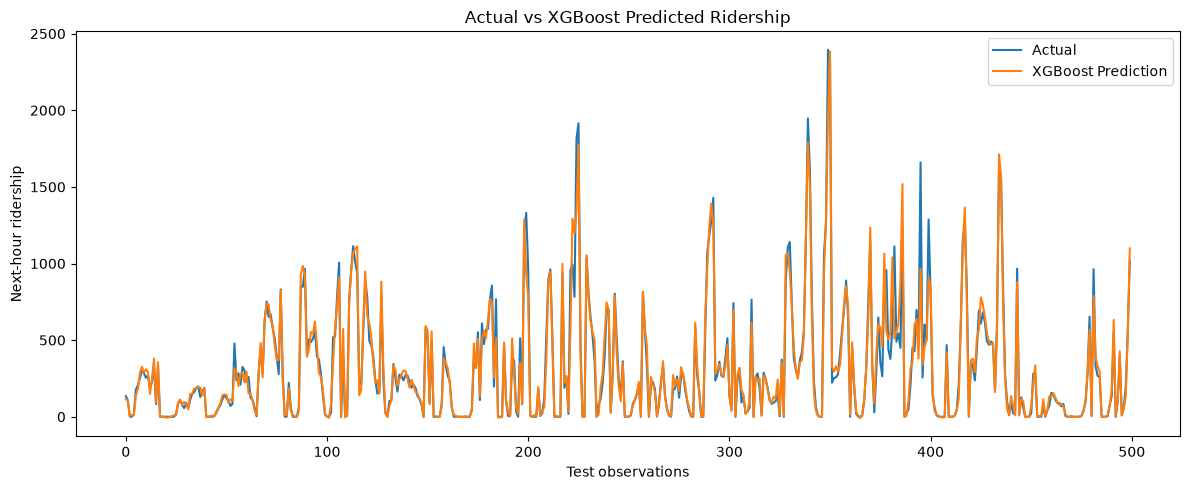

In [34]:
import matplotlib.pyplot as plt

# Compare actual vs predicted ridership
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    y_pred[:500],
    label="XGBoost Prediction"
)

plt.xlabel("Test observations")
plt.ylabel("Next-hour ridership")
plt.title("Actual vs XGBoost Predicted Ridership")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn
import xgboost

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)

Pandas: 3.0.5
NumPy: 2.5.3
Matplotlib: 3.11.2
Scikit-learn: 1.9.1
XGBoost: 3.4.1


In [36]:
entries_path = "../data/bmrcl/station-hourly.csv"
exits_path = "../data/bmrcl/station-hourly-exits.csv"

entries_df = pd.read_csv(
    entries_path,
    sep=";"
)

exits_df = pd.read_csv(
    exits_path,
    sep=";"
)

print("Entries shape:", entries_df.shape)
print("Exits shape:", exits_df.shape)

Entries shape: (92280, 4)
Exits shape: (95616, 4)


In [37]:
# Merge entries and exits
ml_df = pd.merge(
    entries_df,
    exits_df,
    on=["Date", "Hour", "Station"],
    how="inner",
    suffixes=("_entry", "_exit")
)

# Calculate net passenger flow
ml_df["Net_Flow"] = (
    ml_df["Ridership_entry"]
    - ml_df["Ridership_exit"]
)

print("ML dataset shape:", ml_df.shape)
print("Columns:", ml_df.columns.tolist())

ML dataset shape: (92280, 6)
Columns: ['Date', 'Hour', 'Station', 'Ridership_entry', 'Ridership_exit', 'Net_Flow']


In [38]:
# Convert Date into datetime
ml_df["Date"] = pd.to_datetime(ml_df["Date"])

# Time-based features
ml_df["Day_of_Week"] = ml_df["Date"].dt.dayofweek
ml_df["Day_of_Month"] = ml_df["Date"].dt.day
ml_df["Month"] = ml_df["Date"].dt.month

# Weekend indicator
ml_df["Is_Weekend"] = (
    ml_df["Day_of_Week"] >= 5
).astype(int)

# Peak-hour indicator
ml_df["Is_Peak_Hour"] = (
    ml_df["Hour"].isin([7, 8, 9, 17, 18, 19])
).astype(int)

print("Time-based features recreated.")
print("Number of columns:", len(ml_df.columns))

Time-based features recreated.
Number of columns: 11


In [39]:
# Sort data before creating historical features
ml_df = ml_df.sort_values(
    ["Station", "Date", "Hour"]
).reset_index(drop=True)

# Historical ridership features
ml_df["Previous_Hour_Ridership"] = (
    ml_df.groupby("Station")["Ridership_entry"]
    .shift(1)
)

ml_df["Previous_Day_Ridership"] = (
    ml_df.groupby("Station")["Ridership_entry"]
    .shift(24)
)

ml_df["Rolling_3H_Avg"] = (
    ml_df.groupby("Station")["Ridership_entry"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

# Historical exit and flow features
ml_df["Previous_Hour_Exit"] = (
    ml_df.groupby("Station")["Ridership_exit"]
    .shift(1)
)

ml_df["Previous_Hour_Net_Flow"] = (
    ml_df.groupby("Station")["Net_Flow"]
    .shift(1)
)

print("Historical demand and flow features recreated.")

print("\nMissing values:")
print(
    ml_df[
        [
            "Previous_Hour_Ridership",
            "Previous_Day_Ridership",
            "Rolling_3H_Avg",
            "Previous_Hour_Exit",
            "Previous_Hour_Net_Flow"
        ]
    ].isnull().sum()
)

Historical demand and flow features recreated.

Missing values:
Previous_Hour_Ridership      83
Previous_Day_Ridership     1992
Rolling_3H_Avg              249
Previous_Hour_Exit           83
Previous_Hour_Net_Flow       83
dtype: int64


In [40]:
# Remove rows without sufficient historical information

historical_features = [
    "Previous_Hour_Ridership",
    "Previous_Day_Ridership",
    "Rolling_3H_Avg",
    "Previous_Hour_Exit",
    "Previous_Hour_Net_Flow"
]

ml_model_df = ml_df.dropna(
    subset=historical_features
).copy()

print("Original rows:", len(ml_df))
print("Rows available for ML:", len(ml_model_df))
print("Rows removed:", len(ml_df) - len(ml_model_df))

print("\nRemaining missing values:")
print(
    ml_model_df[historical_features]
    .isnull()
    .sum()
)

Original rows: 92280
Rows available for ML: 90288
Rows removed: 1992

Remaining missing values:
Previous_Hour_Ridership    0
Previous_Day_Ridership     0
Rolling_3H_Avg             0
Previous_Hour_Exit         0
Previous_Hour_Net_Flow     0
dtype: int64


In [41]:
# Create the target: next-hour station ridership

ml_model_df["Target_Next_Hour_Ridership"] = (
    ml_model_df.groupby("Station")["Ridership_entry"]
    .shift(-1)
)

print("Target created.")

print(
    "Missing target values:",
    ml_model_df["Target_Next_Hour_Ridership"].isnull().sum()
)

Target created.
Missing target values: 83


In [42]:
# Remove rows where the prediction target is unavailable

ml_model_df = ml_model_df.dropna(
    subset=["Target_Next_Hour_Ridership"]
).copy()

print("Final ML dataset shape:", ml_model_df.shape)

print(
    "Missing target values:",
    ml_model_df["Target_Next_Hour_Ridership"].isnull().sum()
)

Final ML dataset shape: (90205, 17)
Missing target values: 0


In [43]:
# Define input features and prediction target

feature_columns = [
    "Hour",
    "Day_of_Week",
    "Day_of_Month",
    "Month",
    "Is_Weekend",
    "Is_Peak_Hour",
    "Ridership_entry",
    "Ridership_exit",
    "Net_Flow",
    "Previous_Hour_Ridership",
    "Previous_Day_Ridership",
    "Rolling_3H_Avg",
    "Previous_Hour_Exit",
    "Previous_Hour_Net_Flow"
]

X = ml_model_df[feature_columns]

y = ml_model_df["Target_Next_Hour_Ridership"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (90205, 14)
Target shape: (90205,)


In [44]:
from sklearn.preprocessing import OneHotEncoder

# Encode station names
station_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

station_encoded = station_encoder.fit_transform(
    ml_model_df[["Station"]]
)

station_feature_names = (
    station_encoder.get_feature_names_out(["Station"])
)

station_df = pd.DataFrame(
    station_encoded,
    columns=station_feature_names,
    index=ml_model_df.index
)

# Add station features to X
X = pd.concat(
    [X, station_df],
    axis=1
)

print("Updated feature matrix shape:", X.shape)
print("Number of station features:", len(station_feature_names))

Updated feature matrix shape: (90205, 97)
Number of station features: 83


In [45]:
# Create chronological train-test split

sorted_indices = ml_model_df["Date"].sort_values().index

X_sorted = X.loc[sorted_indices]
y_sorted = y.loc[sorted_indices]

split_index = int(len(X_sorted) * 0.80)

X_train = X_sorted.iloc[:split_index]
X_test = X_sorted.iloc[split_index:]

y_train = y_sorted.iloc[:split_index]
y_test = y_sorted.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(
    ml_model_df.loc[X_train.index, "Date"].min(),
    "to",
    ml_model_df.loc[X_train.index, "Date"].max()
)

print("\nTesting period:")
print(
    ml_model_df.loc[X_test.index, "Date"].min(),
    "to",
    ml_model_df.loc[X_test.index, "Date"].max()
)

Training samples: 72164
Testing samples: 18041

Training period:
2025-08-02 00:00:00 to 2025-09-21 00:00:00

Testing period:
2025-09-21 00:00:00 to 2025-09-30 00:00:00


In [46]:
from xgboost import XGBRegressor

# Create XGBoost regression model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model training completed.")

XGBoost model training completed.


In [47]:
# Generate predictions on the unseen test data

y_pred = xgb_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("XGBoost Model Performance")
print("--------------------------")
print(f"MAE  : {mae:.2f} passengers")
print(f"RMSE : {rmse:.2f} passengers")
print(f"R²   : {r2:.4f}")

XGBoost Model Performance
--------------------------
MAE  : 46.85 passengers
RMSE : 87.11 passengers
R²   : 0.9682


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [49]:
# Baseline: predict the next hour using the current hour's ridership

baseline_predictions = ml_model_df.loc[
    X_test.index,
    "Ridership_entry"
]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline Model Performance")
print("--------------------------")
print(f"MAE  : {baseline_mae:.2f} passengers")
print(f"RMSE : {baseline_rmse:.2f} passengers")
print(f"R²   : {baseline_r2:.4f}")

Baseline Model Performance
--------------------------
MAE  : 127.22 passengers
RMSE : 235.88 passengers
R²   : 0.7667


In [50]:
# Calculate improvement of XGBoost over the baseline

mae_improvement = (
    (baseline_mae - mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - rmse) / baseline_rmse
) * 100

print("XGBoost Improvement over Baseline")
print("----------------------------------")
print(f"MAE improvement  : {mae_improvement:.2f}%")
print(f"RMSE improvement : {rmse_improvement:.2f}%")

XGBoost Improvement over Baseline
----------------------------------
MAE improvement  : 63.18%
RMSE improvement : 63.07%


In [51]:
# Inspect the most important features used by XGBoost

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("Top 15 Most Important Features")
print("-------------------------------")
print(feature_importance.head(15).to_string(index=False))

Top 15 Most Important Features
-------------------------------
                                           Feature  Importance
                                   Ridership_entry    0.382776
                            Previous_Day_Ridership    0.098845
                                              Hour    0.042613
                                  Station_Halasuru    0.031670
                                   Station_Trinity    0.030002
                            Station_Benniganahalli    0.023885
Station_Dr. B. R. Ambedkar Station, Vidhana Soudha    0.022191
                            Previous_Hour_Net_Flow    0.019744
   Station_Nadaprabhu Kempegowda Station, Majestic    0.019434
                                          Net_Flow    0.018907
                       Station_Mahatma Gandhi Road    0.017255
                                    Ridership_exit    0.012889
                           Station_Baiyappanahalli    0.012822
                               Station_Cubbon Park    0

In [53]:
# Compare actual and predicted ridership for a small sample

prediction_comparison = pd.DataFrame({
    "Actual_Ridership": y_test.values[:20],
    "Predicted_Ridership": y_pred[:20]
})

prediction_comparison["Absolute_Error"] = (
    prediction_comparison["Actual_Ridership"]
    - prediction_comparison["Predicted_Ridership"]
).abs()

prediction_comparison

,Actual_Ridership,Predicted_Ridership,Absolute_Error
0,134.0,115.496231,18.503769
1,108.0,102.436798,5.563202
2,0.0,1.339130,1.339130
3,0.0,11.815887,11.815887
4,18.0,10.028568,7.971432
5,177.0,138.033661,38.966339
6,206.0,180.149170,25.850830
7,251.0,284.205170,33.205170
8,305.0,325.781250,20.781250
9,284.0,288.340668,4.340668


In [54]:
import joblib

# Save the trained XGBoost model
joblib.dump(
    xgb_model,
    "../outputs/xgboost_crowd_prediction_model.joblib"
)

# Save the station encoder
joblib.dump(
    station_encoder,
    "../outputs/station_encoder.joblib"
)

print("XGBoost model saved successfully.")
print("Station encoder saved successfully.")

XGBoost model saved successfully.
Station encoder saved successfully.


In [ ]:
import os

model_path = "../outputs/xgboost_crowd_prediction_model.joblib"
encoder_path = "../outputs/station_encoder.joblib"

print("Model file exists:", os.path.exists(model_path))
print("Encoder file exists:", os.path.exists(encoder_path))
print("\nModel size:", os.path.getsize(model_path), "bytes")
print("Encoder size:", os.path.getsize(encoder_path), "bytes")

Model file exists: True
Encoder file exists: True

Model size: 1352756 bytes
Encoder size: 2565 bytes


In [56]:
hour_check = (
    ml_df
    .sort_values(["Station", "Date", "Hour"])
    .groupby("Station")
    .apply(
        lambda x: (
            x["Date"] + pd.to_timedelta(x["Hour"], unit="h")
        ).diff().dropna().dt.total_seconds().div(3600)
    )
)

print("Total hourly gaps found:", (hour_check != 1).sum())
print("Largest gap in hours:", hour_check.max())

Total hourly gaps found: 91
Largest gap in hours: 313.0


In [58]:
ml_target_check = ml_df[
    [
        "Station",
        "Date",
        "Hour",
        "Ridership_entry"
    ]
].copy()

# Create an exact timestamp for every station-hour record
ml_target_check["Timestamp"] = (
    ml_target_check["Date"]
    + pd.to_timedelta(
        ml_target_check["Hour"],
        unit="h"
    )
)

# Create the timestamp we want to predict:
# exactly one calendar hour later
ml_target_check["Target_Timestamp"] = (
    ml_target_check["Timestamp"]
    + pd.Timedelta(hours=1)
)

# Keep only the columns needed to find the actual next-hour record
target_data = ml_target_check[
    [
        "Station",
        "Timestamp",
        "Ridership_entry"
    ]
].rename(
    columns={
        "Timestamp": "Target_Timestamp",
        "Ridership_entry": "Target_Next_Hour_Ridership"
    }
)

# Match each record with the same station exactly one hour later
valid_next_hour = ml_target_check.merge(
    target_data,
    on=["Station", "Target_Timestamp"],
    how="inner"
)

print("Original rows:", len(ml_target_check))
print(
    "Valid true next-hour targets:",
    len(valid_next_hour)
)
print(
    "Rows without a true next-hour target:",
    len(ml_target_check) - len(valid_next_hour)
)

Original rows: 92280
Valid true next-hour targets: 92106
Rows without a true next-hour target: 174


In [59]:
# Create exact timestamp in the existing ML dataset
ml_model_df["Timestamp"] = (
    ml_model_df["Date"]
    + pd.to_timedelta(
        ml_model_df["Hour"],
        unit="h"
    )
)

# Remove the old target
ml_model_df = ml_model_df.drop(
    columns=["Target_Next_Hour_Ridership"],
    errors="ignore"
)

# Keep only the correctly matched next-hour targets
correct_target = valid_next_hour[
    [
        "Station",
        "Timestamp",
        "Target_Next_Hour_Ridership"
    ]
]

# Attach the true next-hour target
ml_model_df = ml_model_df.merge(
    correct_target,
    on=["Station", "Timestamp"],
    how="inner"
)

print("Corrected ML dataset shape:", ml_model_df.shape)
print(
    "Missing true next-hour targets:",
    ml_model_df["Target_Next_Hour_Ridership"].isna().sum()
)

Corrected ML dataset shape: (90120, 18)
Missing true next-hour targets: 0


In [60]:
# Rebuild features and target from the corrected ML dataset

feature_columns = [
    "Hour",
    "Day_of_Week",
    "Day_of_Month",
    "Month",
    "Is_Weekend",
    "Is_Peak_Hour",
    "Ridership_entry",
    "Ridership_exit",
    "Net_Flow",
    "Previous_Hour_Ridership",
    "Previous_Day_Ridership",
    "Rolling_3H_Avg",
    "Previous_Hour_Exit",
    "Previous_Hour_Net_Flow"
]

# Numerical features
X = ml_model_df[feature_columns].copy()

# Target: exactly the next calendar hour
y = ml_model_df[
    "Target_Next_Hour_Ridership"
].copy()

# Encode station using the existing encoder
station_encoded = station_encoder.transform(
    ml_model_df[["Station"]]
)

station_feature_names = (
    station_encoder.get_feature_names_out(
        ["Station"]
    )
)

station_df = pd.DataFrame(
    station_encoded,
    columns=station_feature_names,
    index=ml_model_df.index
)

# Combine numerical + station features
X = pd.concat(
    [X, station_df],
    axis=1
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target missing:", y.isna().sum())

X shape: (90120, 97)
y shape: (90120,)
Target missing: 0


In [61]:
# Sort the corrected dataset chronologically
sorted_indices = (
    ml_model_df["Date"]
    .sort_values()
    .index
)

X_sorted = X.loc[sorted_indices]
y_sorted = y.loc[sorted_indices]

# Use 80% of the unique dates for training
unique_dates = (
    ml_model_df.loc[
        sorted_indices,
        "Date"
    ]
    .dt.normalize()
    .drop_duplicates()
    .sort_values()
)

split_date_index = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates.iloc[
    split_date_index
]

train_mask = (
    ml_model_df.loc[
        X_sorted.index,
        "Date"
    ] < split_date
)

test_mask = ~train_mask

X_train = X_sorted.loc[train_mask]
X_test = X_sorted.loc[test_mask]

y_train = y_sorted.loc[train_mask]
y_test = y_sorted.loc[test_mask]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print(
    "Training period:",
    ml_model_df.loc[
        X_train.index,
        "Date"
    ].min().date(),
    "to",
    ml_model_df.loc[
        X_train.index,
        "Date"
    ].max().date()
)
print(
    "Testing period:",
    ml_model_df.loc[
        X_test.index,
        "Date"
    ].min().date(),
    "to",
    ml_model_df.loc[
        X_test.index,
        "Date"
    ].max().date()
)

Training samples: 70283
Testing samples: 19837
Training period: 2025-08-02 to 2025-09-20
Testing period: 2025-09-21 to 2025-09-30


In [62]:
from xgboost import XGBRegressor

corrected_xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

corrected_xgb_model.fit(
    X_train,
    y_train
)

print("Corrected XGBoost model training completed.")

Corrected XGBoost model training completed.


In [63]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Predictions on unseen test data
corrected_y_pred = corrected_xgb_model.predict(
    X_test
)

# Evaluation metrics
corrected_mae = mean_absolute_error(
    y_test,
    corrected_y_pred
)

corrected_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        corrected_y_pred
    )
)

corrected_r2 = r2_score(
    y_test,
    corrected_y_pred
)

print("Corrected XGBoost Performance")
print("--------------------------------")
print("MAE :", round(corrected_mae, 2))
print("RMSE:", round(corrected_rmse, 2))
print("R²  :", round(corrected_r2, 4))

Corrected XGBoost Performance
--------------------------------
MAE : 45.53
RMSE: 84.36
R²  : 0.9691


In [64]:
import joblib

joblib.dump(
    corrected_xgb_model,
    "../outputs/xgboost_crowd_prediction_model.joblib"
)

print(
    "Corrected XGBoost model saved successfully."
)

Corrected XGBoost model saved successfully.


In [65]:
loaded_model = joblib.load(
    "../outputs/xgboost_crowd_prediction_model.joblib"
)

print(
    "Saved model loaded successfully."
)
print(
    "Model type:",
    type(loaded_model).__name__
)

Saved model loaded successfully.
Model type: XGBRegressor
